In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import kagglehub
import json

In [ ]:
path = kagglehub.dataset_download("pernavjain/synthetic-emails")
print("Path to dataset files:", path)

In [3]:
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
data = pd.read_csv(f"{path}/support_dataset.csv")
data.head()
team_map = {
    "billing": 0,
    "engineering": 1,
    "CS": 2,
    "sales": 3,
    "security": 4
}
data["team"] = data["team"].map(team_map)

In [5]:
X = data["email"]
y_team = data["team"]
y_urgency = data["urgency_score"]

X_train, X_temp, y_team_train, y_team_temp, y_urgency_train, y_urgency_temp = train_test_split(
    X,
    y_team,
    y_urgency,
    test_size=0.30,
    stratify=y_team,
    random_state=42
)

X_val, X_test, y_team_val, y_team_test, y_urgency_val, y_urgency_test = train_test_split(
    X_temp,
    y_team_temp,
    y_urgency_temp,
    test_size=0.5,
    stratify=y_team_temp,
    random_state=42
)

In [6]:
train_ds = tf.data.Dataset.from_tensor_slices( 
    ( 
        X_train.values, 
        { 
            "team": y_team_train.values, 
            "urgency": y_urgency_train.values 
        } 
    ) 
)
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_val.values,
        {
            "team": y_team_val.values,
            "urgency": y_urgency_val.values
        }
    )
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_test.values,
        {
            "team": y_team_test.values,
            "urgency": y_urgency_test.values
        }
    )
)


train_ds = (
    train_ds
    .cache()
    .shuffle(len(X_train), seed=42)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_ds
    .batch(32)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_ds
    .batch(32)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

I0000 00:00:1782597635.322949      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
tfhub_encoder = 'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3'
tfhub_preprocess = 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'

In [8]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  preprocessing_layer = hub.KerasLayer(tfhub_preprocess, name='preprocessing')
  encoder_inputs = preprocessing_layer(text_input)
  encoder = hub.KerasLayer(tfhub_encoder, trainable=True, name='BERT_encoder')
  outputs = encoder(encoder_inputs)
  net = outputs['pooled_output']
  net = tf.keras.layers.Dropout(0.1)(net)
  team_output = tf.keras.layers.Dense(5, name='team')(net)
  urgency_output = tf.keras.layers.Dense(1, name='urgency')(net)
  return tf.keras.Model(inputs=text_input, outputs=[team_output, urgency_output])
classifier_model = build_classifier_model()
classifier_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

In [9]:
losses = {
    "team": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    "urgency": tf.keras.losses.MeanSquaredError()
}
metrics = {
    "team": tf.keras.metrics.SparseCategoricalAccuracy(),
    "urgency": tf.keras.metrics.MeanAbsoluteError()
}
loss_weights = {"team": 1.0, "urgency": 8.0}

In [10]:
epochs = 20
steps_per_epoch = train_ds.cardinality().numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 2e-5
optimizer = optimization.create_optimizer(
    init_lr=init_lr,
		num_train_steps=num_train_steps,
		num_warmup_steps=num_warmup_steps,
		optimizer_type='adamw'
)

In [11]:
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

In [13]:
classifier_model.compile(optimizer=optimizer, loss=losses, metrics=metrics, loss_weights=loss_weights)

In [14]:
print(f'Training model with {tfhub_encoder}')
history = classifier_model.fit(
    x=train_ds,
	validation_data=val_ds,
	epochs=epochs,
    callbacks=[checkpoint, early_stop]
)

Training model with https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Epoch 1/20
329/329 [==============================] - ETA: 0s - loss: 2.6022 - team_loss: 1.4369 - urgency_loss: 0.1457 - team_sparse_categorical_accuracy: 0.4530 - urgency_mean_absolute_error: 0.2779
Epoch 1: val_loss improved from inf to 0.74832, saving model to best_model.keras
329/329 [==============================] - 201s 556ms/step - loss: 2.6022 - team_loss: 1.4369 - urgency_loss: 0.1457 - team_sparse_categorical_accuracy: 0.4530 - urgency_mean_absolute_error: 0.2779 - val_loss: 0.7483 - val_team_loss: 0.5639 - val_urgency_loss: 0.0231 - val_team_sparse_categorical_accuracy: 0.9204 - val_urgency_mean_absolute_error: 0.1217
Epoch 2/20
329/329 [==============================] - ETA: 0s - loss: 0.5984 - team_loss: 0.1986 - urgency_loss: 0.0500 - team_sparse_categorical_accuracy: 0.9876 - urgency_mean_absolute_error: 0.1766
Epoch 2: val_loss improved from 0.74832 to 0.18122, saving model to best_mode

In [15]:
print(history.history["team_loss"])
print(history.history["urgency_loss"])
print(history.history["val_team_loss"])
print(history.history["val_urgency_loss"])
print(history.history["val_urgency_mean_absolute_error"])

[1.4368904829025269, 0.19857320189476013, 0.03650708869099617, 0.02107049524784088, 0.014996384270489216, 0.011390449479222298, 0.009031138382852077, 0.007820256985723972, 0.006494371686130762, 0.006076501216739416]
[0.1456606686115265, 0.049978189170360565, 0.028422009199857712, 0.019910629838705063, 0.015988865867257118, 0.013336876407265663, 0.011243700049817562, 0.010104692541062832, 0.009062127210199833, 0.008557263761758804]
[0.5638662576675415, 0.042555611580610275, 0.025304147973656654, 0.015437684953212738, 0.009354122914373875, 0.007773633114993572, 0.0071811615489423275, 0.007698891684412956, 0.005885861348360777, 0.005387418903410435]
[0.02305627055466175, 0.017332961782813072, 0.008709820918738842, 0.010638444684445858, 0.008292737416923046, 0.006556098349392414, 0.005801676772534847, 0.006889588665217161, 0.0063161239959299564, 0.0066333916038274765]
[0.12169130146503448, 0.10148297250270844, 0.07170505821704865, 0.08333995938301086, 0.07114072144031525, 0.062617599964141

In [16]:
results = classifier_model.evaluate(test_ds)
print(dict(zip(classifier_model.metrics_names, results)))

71/71 [==============================] - 13s 177ms/step - loss: 0.0555 - team_loss: 0.0072 - urgency_loss: 0.0060 - team_sparse_categorical_accuracy: 1.0000 - urgency_mean_absolute_error: 0.0587
{'loss': 0.05548648536205292, 'team_loss': 0.0071615539491176605, 'urgency_loss': 0.006040616892278194, 'team_sparse_categorical_accuracy': 1.0, 'urgency_mean_absolute_error': 0.05867285653948784}


dict_keys(['loss', 'team_loss', 'urgency_loss', 'team_sparse_categorical_accuracy', 'urgency_mean_absolute_error', 'val_loss', 'val_team_loss', 'val_urgency_loss', 'val_team_sparse_categorical_accuracy', 'val_urgency_mean_absolute_error'])


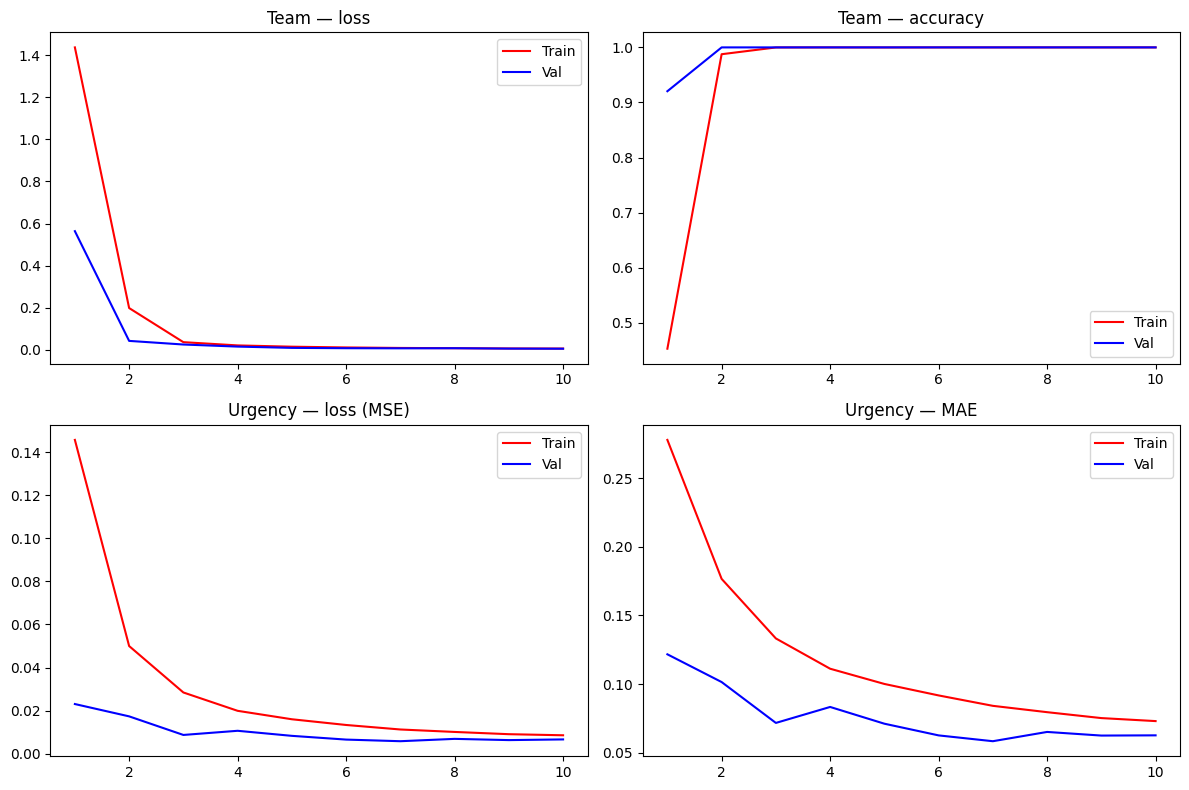

In [17]:
history_dict = history.history
print(history_dict.keys())

epochs_range = range(1, len(history_dict['loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(epochs_range, history_dict['team_loss'], 'r', label='Train')
axes[0,0].plot(epochs_range, history_dict['val_team_loss'], 'b', label='Val')
axes[0,0].set_title('Team — loss')
axes[0,0].legend()

axes[0,1].plot(epochs_range, history_dict['team_sparse_categorical_accuracy'], 'r', label='Train')
axes[0,1].plot(epochs_range, history_dict['val_team_sparse_categorical_accuracy'], 'b', label='Val')
axes[0,1].set_title('Team — accuracy')
axes[0,1].legend()

axes[1,0].plot(epochs_range, history_dict['urgency_loss'], 'r', label='Train')
axes[1,0].plot(epochs_range, history_dict['val_urgency_loss'], 'b', label='Val')
axes[1,0].set_title('Urgency — loss (MSE)')
axes[1,0].legend()

axes[1,1].plot(epochs_range, history_dict['urgency_mean_absolute_error'], 'r', label='Train')
axes[1,1].plot(epochs_range, history_dict['val_urgency_mean_absolute_error'], 'b', label='Val')
axes[1,1].set_title('Urgency — MAE')
axes[1,1].legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Validation Loss')

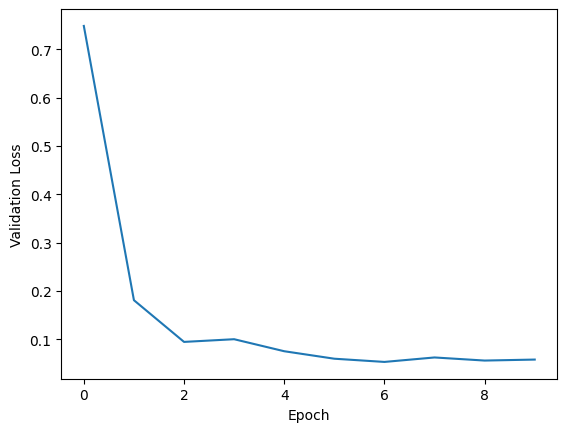

In [18]:
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

In [ ]:
with open("id_to_team.json", "w") as f:
    json.dump(team_map, f)

In [ ]:
classifier_model.save(
    "customer_support_ticket_dispatcher_v1.keras"
)